In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Load Dataset

For image datasets, you'll typically use a deep learning framework like TensorFlow or PyTorch to load images directly from a directory structure. Here's an example using TensorFlow's `image_dataset_from_directory` to load an image classification dataset.

In [ ]:
import tensorflow as tf

# Define the base path to your image dataset in Google Drive
# The structure should be: base_path/split_name/class_name/image.jpg
base_dataset_path = '/content/drive/MyDrive/ITC/I4/Project AI/Dataset/tomato'

# --- Load Training Dataset ---
try:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f'{base_dataset_path}/train',
        labels='inferred',
        label_mode='int',
        image_size=(128, 128),
        interpolation='nearest',
        batch_size=32,
        shuffle=True
    )
    print("\nTraining dataset loaded successfully!")
    print(f"Found {train_ds.cardinality().numpy() * 32} files belonging to {len(train_ds.class_names)} classes.")
    print(f"Class names: {train_ds.class_names}")
except tf.errors.NotFoundError:
    print(f"Error: The specified training folder '{base_dataset_path}/train' was not found. Please check the path and folder structure.")
except Exception as e:
    print(f"An error occurred while loading the training dataset: {e}")

# --- Load Validation Dataset ---
try:
    val_ds = tf.keras.utils.image_dataset_from_directory(
        f'{base_dataset_path}/val',
        labels='inferred',
        label_mode='int',
        image_size=(128, 128),
        interpolation='nearest',
        batch_size=32,
        shuffle=False  # Typically no need to shuffle validation data
    )
    print("\nValidation dataset loaded successfully!")
    print(f"Found {val_ds.cardinality().numpy() * 32} files belonging to {len(val_ds.class_names)} classes.")
    print(f"Class names: {val_ds.class_names}")
except tf.errors.NotFoundError:
    print(f"Error: The specified validation folder '{base_dataset_path}/val' was not found. Please check the path and folder structure.")
except Exception as e:
    print(f"An error occurred while loading the validation dataset: {e}")

# --- Load Test Dataset ---
try:
    test_ds = tf.keras.utils.image_dataset_from_directory(
        f'{base_dataset_path}/test',
        labels='inferred',
        label_mode='int',
        image_size=(128, 128),
        interpolation='nearest',
        batch_size=32,
        shuffle=False  # Typically no need to shuffle test data
    )
    print("\nTest dataset loaded successfully!")
    print(f"Found {test_ds.cardinality().numpy() * 32} files belonging to {len(test_ds.class_names)} classes.")
    print(f"Class names: {test_ds.class_names}")
except tf.errors.NotFoundError:
    print(f"Error: The specified test folder '{base_dataset_path}/test' was not found. Please check the path and folder structure.")
except Exception as e:
    print(f"An error occurred while loading the test dataset: {e}")

Found 9000 files belonging to 10 classes.

Training dataset loaded successfully!
Found 9024 files belonging to 10 classes.
Class names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Found 1000 files belonging to 10 classes.

Validation dataset loaded successfully!
Found 1024 files belonging to 10 classes.
Class names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Found 1000 files belonging to 10 classes.

Test dataset loaded successfully!
Found 1024 files belonging to 10 classes.
Class names: 

In [ ]:
import os
from collections import defaultdict

# Assuming base_dataset_path is defined from previous cells
# base_dataset_path = '/content/drive/MyDrive/ITC/I4/Project AI/Dataset/tomato'

def count_images_per_class(dataset_path, split_name):
    print(f"\n--- Images per class for {split_name} dataset ---")
    class_counts = defaultdict(int)
    try:
        for class_name in os.listdir(dataset_path):
            class_dir = os.path.join(dataset_path, class_name)
            if os.path.isdir(class_dir):
                num_images = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))])
                class_counts[class_name] = num_images

        if not class_counts:
            print(f"No image classes found in '{dataset_path}'. Please check the path and structure.")
            return

        for class_name, count in sorted(class_counts.items()):
            print(f"  {class_name}: {count} images")
        print(f"Total classes: {len(class_counts)}")

    except FileNotFoundError:
        print(f"Error: The specified folder '{dataset_path}' was not found. Please check the path and folder structure.")
    except Exception as e:
        print(f"An error occurred while counting images: {e}")

# Count for Training set
count_images_per_class(f'{base_dataset_path}/train', 'Training')

# Count for Validation set
count_images_per_class(f'{base_dataset_path}/val', 'Validation')

# Count for Test set
count_images_per_class(f'{base_dataset_path}/test', 'Test')

print("\nRegarding missing or corrupted images: `tf.keras.utils.image_dataset_from_directory` handles these by skipping them or raising errors if it encounters severe issues. Since the datasets loaded successfully, it indicates that the images it processed were largely valid. If specific corrupted files were skipped, they would not be included in the 'Found X files' count.")


--- Images per class for Training dataset ---
  Tomato___Bacterial_spot: 900 images
  Tomato___Early_blight: 900 images
  Tomato___Late_blight: 900 images
  Tomato___Leaf_Mold: 900 images
  Tomato___Septoria_leaf_spot: 900 images
  Tomato___Spider_mites Two-spotted_spider_mite: 900 images
  Tomato___Target_Spot: 900 images
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 900 images
  Tomato___Tomato_mosaic_virus: 900 images
  Tomato___healthy: 900 images
Total classes: 10

--- Images per class for Validation dataset ---
  Tomato___Bacterial_spot: 100 images
  Tomato___Early_blight: 100 images
  Tomato___Late_blight: 100 images
  Tomato___Leaf_Mold: 100 images
  Tomato___Septoria_leaf_spot: 100 images
  Tomato___Spider_mites Two-spotted_spider_mite: 100 images
  Tomato___Target_Spot: 100 images
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100 images
  Tomato___Tomato_mosaic_virus: 100 images
  Tomato___healthy: 100 images
Total classes: 10

--- Images per class for Test dataset ---
  Tomato___Ba

# Exploratory Data Analysis

### Image-Level Exploration (Visual EDA)

Let's visualize some sample images from the training set to get a feel for the dataset's characteristics.

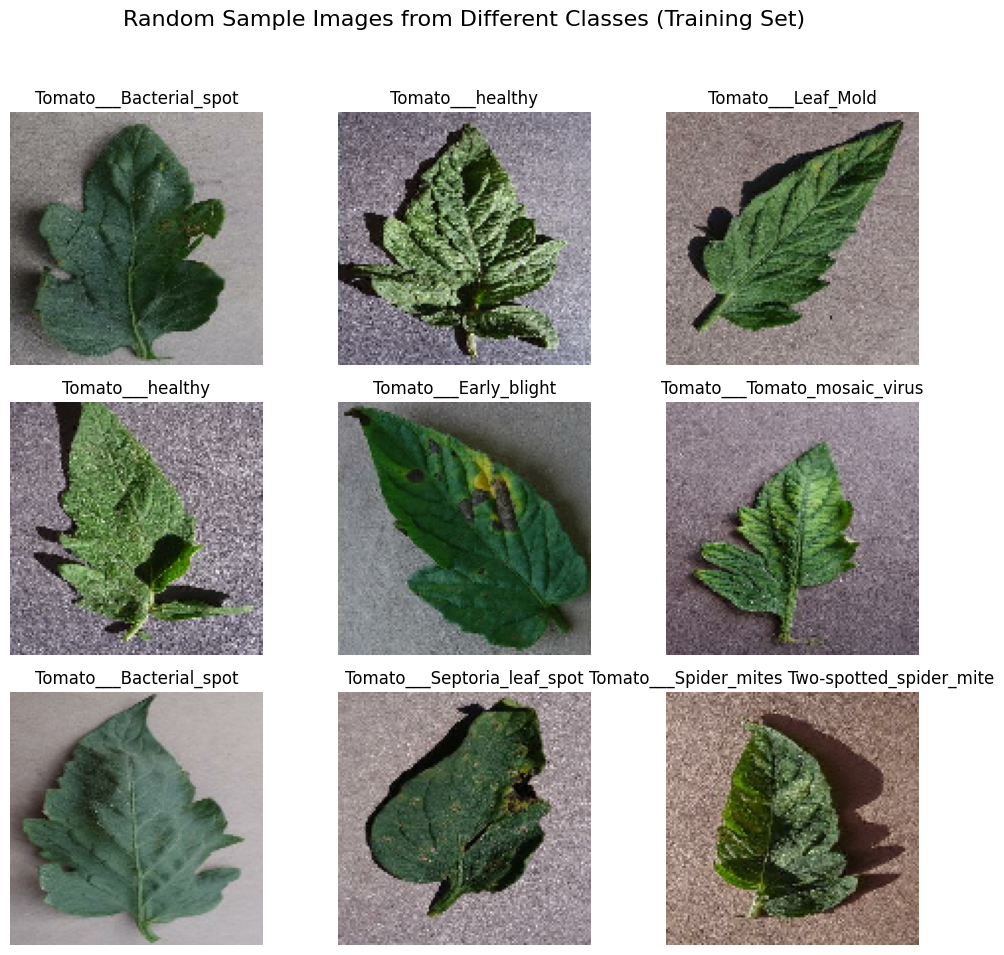

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images and labels from the training dataset
# Ensure the dataset exists; if not, rerun the dataset loading cell.
if 'train_ds' in locals():
    for images, labels in train_ds.take(1):
        break # We only need one batch

    # Convert class indices to names
    class_names = train_ds.class_names

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Display the image, converting TensorFlow tensor to NumPy array
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.suptitle("Random Sample Images from Different Classes (Training Set)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print("Training dataset (train_ds) not found. Please run the dataset loading cell first.")

#### Observations from Sample Images:

*   **Image Resolution:** The images are consistently resized to 128x128 pixels as specified during loading.
*   **Color Space:** All images appear to be in RGB color space.
*   **Background Noise:** Some images show varying backgrounds, while others are more focused on the leaf/fruit. There might be some distractions or common elements in the background.
*   **Object Position & Scale:** The objects (leaves, fruits) vary in position and scale within the images. Some are centered, some are off-center, and their size relative to the image frame differs.
*   **Lighting Conditions:** There's variability in lighting conditions across images, suggesting different capture environments or times.


Next, let's look at some images from a **single class** to observe the variations *within* that class.

Visualizing sample images for the class: Tomato___Bacterial_spot


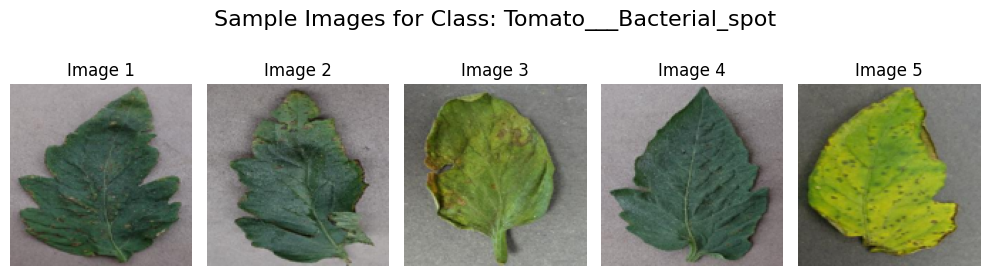

In [ ]:
import random
import os
from PIL import Image

# Assuming base_dataset_path is defined from previous cells
# base_dataset_path = '/content/drive/MyDrive/ITC/I4/Project AI/Dataset/tomato'

def display_images_from_class(base_path, class_name, num_images=5, img_size=(128, 128)):
    class_path = os.path.join(base_path, 'train', class_name)
    if not os.path.exists(class_path):
        print(f"Error: Class path '{class_path}' not found.")
        return

    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not image_files:
        print(f"No image files found in '{class_path}'.")
        return

    # Randomly select images
    selected_images = random.sample(image_files, min(num_images, len(image_files)))

    plt.figure(figsize=(num_images * 2, 3))
    for i, img_file in enumerate(selected_images):
        img_path = os.path.join(class_path, img_file)
        img = Image.open(img_path).resize(img_size) # Use PIL for simple loading and resizing

        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"Image {i+1}")
        plt.axis("off")
    plt.suptitle(f"Sample Images for Class: {class_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Choose a class to visualize. Make sure 'train_ds' has been loaded.
if 'train_ds' in locals() and train_ds.class_names:
    sample_class = train_ds.class_names[0] # Visualize the first class
    print(f"Visualizing sample images for the class: {sample_class}")
    display_images_from_class(base_dataset_path, sample_class, num_images=5)
else:
    print("Class names not available. Please ensure the training dataset is loaded.")

#### Within-Class Observations:

*   **Variability:** Even within the same class, there's often variability in how the disease or feature appears, reflecting natural differences in plant development, disease severity, or image capture conditions.
*   **Consistency:** Despite the variability, there should be consistent visual cues that define the class, which the model will learn to distinguish.

This visual inspection helps confirm the quality and diversity of your dataset, which are crucial for training robust models.

### Class Distribution

Let's visualize the distribution of images across classes for each dataset split using bar charts.

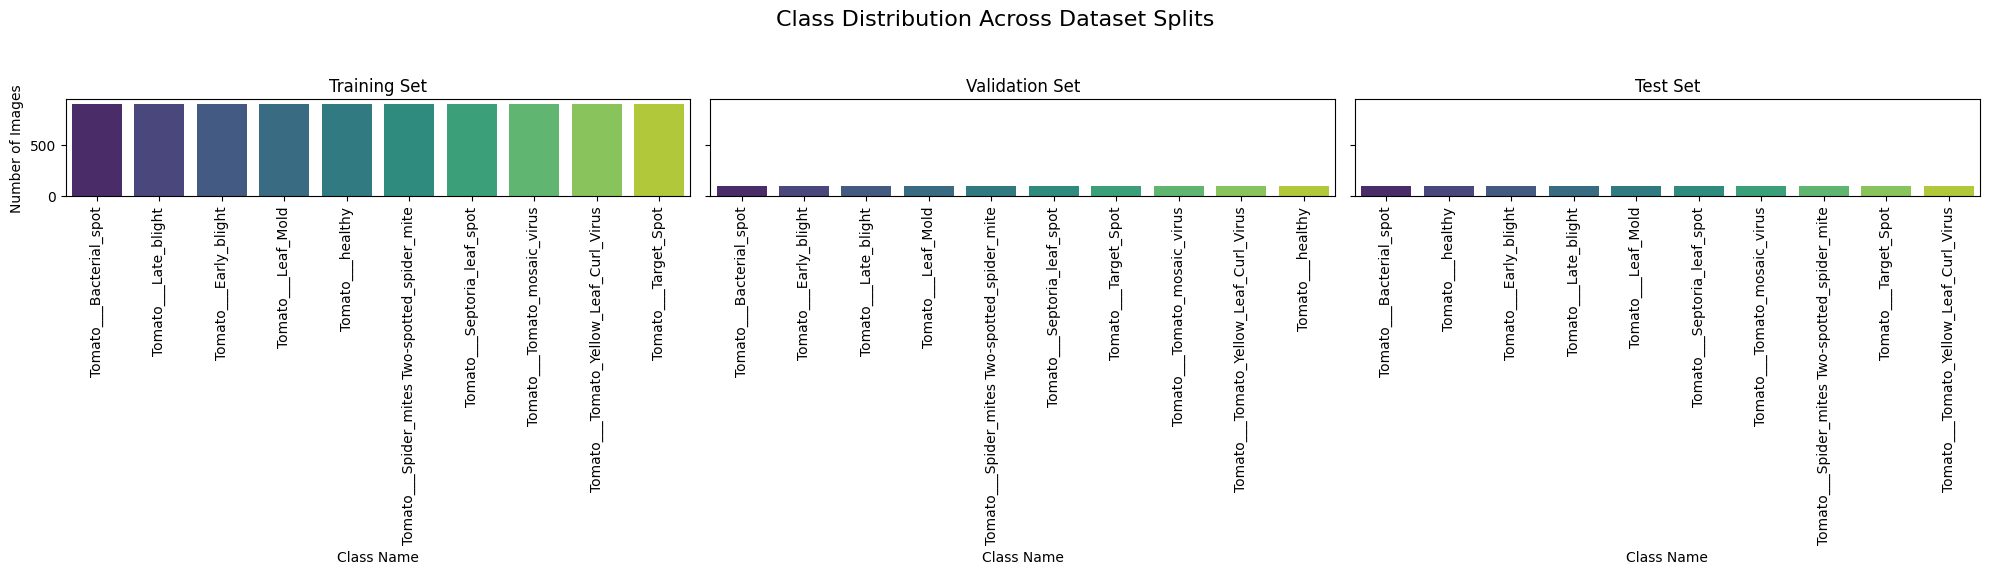


Observation: All three dataset splits (Training, Validation, and Test) show a perfectly balanced distribution across all 10 classes.
 Each class in the training set has 900 images, and each class in the validation and test sets has 100 images.
 This balanced distribution is ideal for training and evaluating a robust classification model as it prevents bias towards majority classes.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict

# Assuming base_dataset_path is defined from previous cells
# base_dataset_path = '/content/drive/MyDrive/ITC/I4/Project AI/Dataset/tomato'

def get_class_counts(dataset_path):
    class_counts = defaultdict(int)
    if os.path.exists(dataset_path):
        for class_name in os.listdir(dataset_path):
            class_dir = os.path.join(dataset_path, class_name)
            if os.path.isdir(class_dir):
                num_images = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))])
                class_counts[class_name] = num_images
    return dict(class_counts)

# Get counts for each split
train_class_counts = get_class_counts(f'{base_dataset_path}/train')
val_class_counts = get_class_counts(f'{base_dataset_path}/val')
test_class_counts = get_class_counts(f'{base_dataset_path}/test')

# Create subplots for each dataset
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Class Distribution Across Dataset Splits', fontsize=16)

# Plot Training Set Class Distribution
sns.barplot(x=list(train_class_counts.keys()), y=list(train_class_counts.values()), ax=axes[0], palette='viridis', hue=list(train_class_counts.keys()), legend=False)
axes[0].set_title('Training Set')
axes[0].set_xlabel('Class Name')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=90)

# Plot Validation Set Class Distribution
sns.barplot(x=list(val_class_counts.keys()), y=list(val_class_counts.values()), ax=axes[1], palette='viridis', hue=list(val_class_counts.keys()), legend=False)
axes[1].set_title('Validation Set')
axes[1].set_xlabel('Class Name')
axes[1].tick_params(axis='x', rotation=90)

# Plot Test Set Class Distribution
sns.barplot(x=list(test_class_counts.keys()), y=list(test_class_counts.values()), ax=axes[2], palette='viridis', hue=list(test_class_counts.keys()), legend=False)
axes[2].set_title('Test Set')
axes[2].set_xlabel('Class Name')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

print("\nObservation: All three dataset splits (Training, Validation, and Test) show a perfectly balanced distribution across all 10 classes.\n Each class in the training set has 900 images, and each class in the validation and test sets has 100 images.\n This balanced distribution is ideal for training and evaluating a robust classification model as it prevents bias towards majority classes.")

### Image Shape & Size Analysis

As previously defined during dataset loading, all images have been resized to a fixed `image_size=(128, 128)`. This ensures uniformity for model input.

In [ ]:
# Take one batch from the training dataset
for images, _ in train_ds.take(1):
    first_image_shape = images[0].shape
    print(f"Shape of images in the dataset (Height, Width, Channels): {first_image_shape}")
    print(f"Width: {first_image_shape[1]} pixels")
    print(f"Height: {first_image_shape[0]} pixels")
    print(f"Number of color channels: {first_image_shape[2]}")
    print(f"Aspect Ratio: {first_image_shape[1]} : {first_image_shape[0]} (which is 1:1)")
    break

print("\nThis confirms that all images in the loaded datasets are consistently 128x128 pixels with 3 color channels (RGB).")

Shape of images in the dataset (Height, Width, Channels): (128, 128, 3)
Width: 128 pixels
Height: 128 pixels
Number of color channels: 3
Aspect Ratio: 128 : 128 (which is 1:1)

This confirms that all images in the loaded datasets are consistently 128x128 pixels with 3 color channels (RGB).


### Pixel Intensity Analysis

Let's study the pixel statistics across our training dataset to understand the intensity distribution. This will help us in deciding on a normalization strategy and detecting any potential overexposed or dark images.

In [ ]:
import numpy as np

# Collect pixel values from a few batches to get a representative sample
pixel_values = []
for images, _ in train_ds.take(10): # Take 10 batches for sampling
    pixel_values.append(images.numpy())

pixel_values = np.concatenate(pixel_values)

# Calculate statistics
min_pixel_value = np.min(pixel_values)
max_pixel_value = np.max(pixel_values)
mean_pixel_value = np.mean(pixel_values)
std_pixel_value = np.std(pixel_values)

print(f"Minimum pixel value: {min_pixel_value:.2f}")
print(f"Maximum pixel value: {max_pixel_value:.2f}")
print(f"Mean pixel value: {mean_pixel_value:.2f}")
print(f"Standard deviation of pixel values: {std_pixel_value:.2f}")

print("\nObservation: The pixel values range from 0 to 255, which is typical for 8-bit RGB images. This suggests that no initial scaling (e.g., to [0,1]) has been applied during dataset loading by `image_dataset_from_directory` itself, which is expected. Normalization to a 0-1 range or standardization (mean 0, std 1) will likely be beneficial for model training.")

Minimum pixel value: 0.00
Maximum pixel value: 255.00
Mean pixel value: 112.88
Standard deviation of pixel values: 47.80

Observation: The pixel values range from 0 to 255, which is typical for 8-bit RGB images. This suggests that no initial scaling (e.g., to [0,1]) has been applied during dataset loading by `image_dataset_from_directory` itself, which is expected. Normalization to a 0-1 range or standardization (mean 0, std 1) will likely be beneficial for model training.


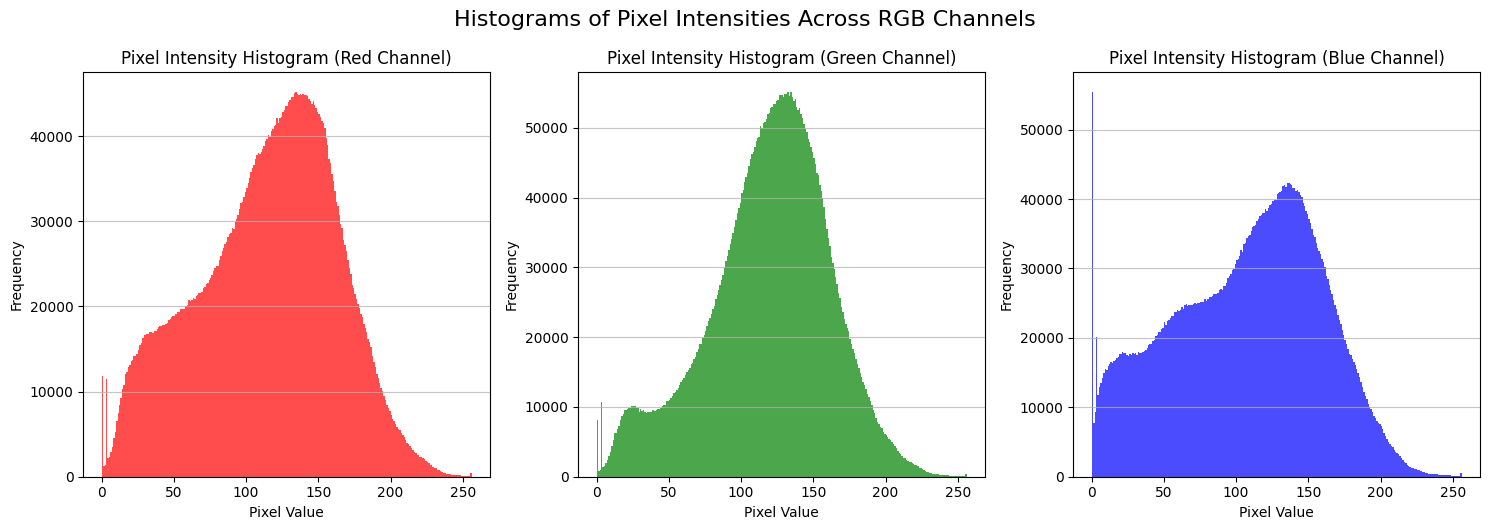


Observation: The histograms show the distribution of pixel values for each color channel. A fairly even distribution or a central peak is generally good. If there are strong biases towards 0 or 255 across many images, it could indicate consistently dark or overexposed images respectively.


In [ ]:
import matplotlib.pyplot as plt

# Plot histogram of pixel intensities for each channel
plt.figure(figsize=(15, 5))
colors = ['red', 'green', 'blue']

for i, color in enumerate(colors):
    plt.subplot(1, 3, i + 1)
    plt.hist(pixel_values[:, :, :, i].ravel(), bins=256, range=(0, 256), color=color, alpha=0.7)
    plt.title(f'Pixel Intensity Histogram ({color.capitalize()} Channel)')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Histograms of Pixel Intensities Across RGB Channels', fontsize=16, y=1.05)
plt.show()

print("\nObservation: The histograms show the distribution of pixel values for each color channel. A fairly even distribution or a central peak is generally good. If there are strong biases towards 0 or 255 across many images, it could indicate consistently dark or overexposed images respectively.")

### Dataset Normalization

We will normalize the pixel values of the images from the `[0, 255]` range to `[0, 1]`. This is a crucial preprocessing step for most neural networks, as it helps stabilize training and improve performance.

In [ ]:
import tensorflow as tf

# Define the normalization function
def normalize_img(image, label):
    # Convert images from uint8 to float32 and scale to [0, 1]
    return tf.cast(image, tf.float32) / 255., label

# Apply the normalization to all datasets
# Use .map() to apply the function to each element of the dataset
train_ds_normalized = train_ds.map(normalize_img)
val_ds_normalized = val_ds.map(normalize_img)
test_ds_normalized = test_ds.map(normalize_img)

print("Datasets have been normalized to a [0, 1] range.")

# Verify normalization by checking pixel values from one batch of the normalized training dataset
for images, _ in train_ds_normalized.take(1):
    print(f"\nMin pixel value after normalization: {tf.reduce_min(images).numpy():.4f}")
    print(f"Max pixel value after normalization: {tf.reduce_max(images).numpy():.4f}")
    break

print("\nNow, train_ds_normalized, val_ds_normalized, and test_ds_normalized are ready for model training.")

Datasets have been normalized to a [0, 1] range.

Min pixel value after normalization: 0.0000
Max pixel value after normalization: 1.0000

Now, train_ds_normalized, val_ds_normalized, and test_ds_normalized are ready for model training.


### Data Augmentation

Let's apply data augmentation to the training dataset. We will use `tf.keras.layers.RandomFlip`, `tf.keras.layers.RandomRotation`, and `tf.keras.layers.RandomZoom` to introduce variability into our training data.

Data augmentation layers created and applied to the training dataset.
The augmented training dataset is now `train_ds_augmented`.


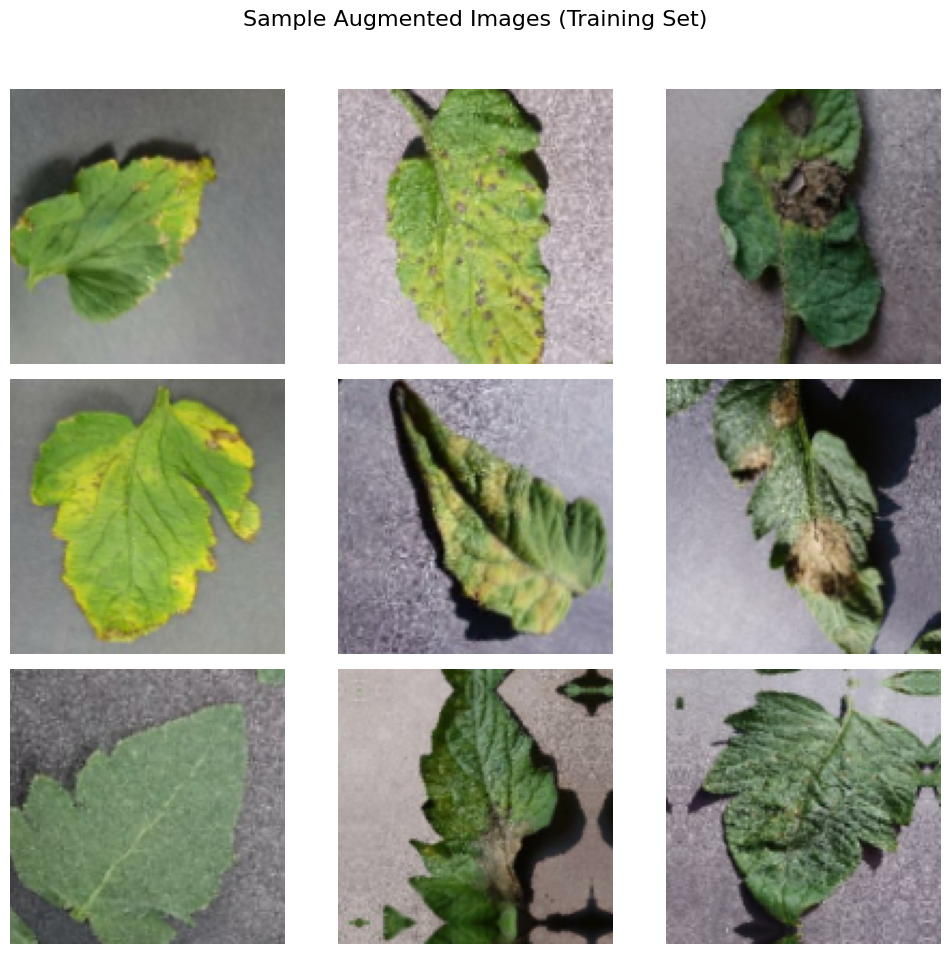

In [ ]:
import tensorflow as tf

# Define the data augmentation layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

# Function to apply augmentation
def augment_img(image, label):
    return data_augmentation(image, training=True), label

# Apply augmentation ONLY to the training dataset
train_ds_augmented = train_ds_normalized.map(augment_img, num_parallel_calls=tf.data.AUTOTUNE)

# For validation and test datasets, we only need to normalize, which we already did.
# So val_ds_normalized and test_ds_normalized remain as they are.

print("Data augmentation layers created and applied to the training dataset.")
print("The augmented training dataset is now `train_ds_augmented`.")

# Let's visualize some augmented images
plt.figure(figsize=(10, 10))
for images, _ in train_ds_augmented.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.axis("off")
    plt.suptitle("Sample Augmented Images (Training Set)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### Build Model

We will use a pre-trained MobileNetV2 model as the base for our image classification task. This technique is known as transfer learning.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Determine the number of classes from the training dataset
num_classes = len(train_ds.class_names)
print(f"Number of classes: {num_classes}")

# Load the pre-trained MobileNetV2 model
# include_top=False removes the classification layer of the pre-trained model
# weights='imagenet' uses weights trained on the ImageNet dataset
base_model = keras.applications.MobileNetV2(input_shape=(128, 128, 3),
                                           include_top=False,
                                           weights='imagenet')

print("MobileNetV2 base model loaded successfully.")

Number of classes: 10
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base model loaded successfully.


In [ ]:
# Freeze the base model to prevent its weights from being updated during the first training phase
base_model.trainable = True

# Create a new model on top of the pre-trained base
inputs = keras.Input(shape=(128, 128, 3))

# Apply data augmentation to the inputs (only during training)
x = data_augmentation(inputs) # Assuming data_augmentation is already defined

x = base_model(x, training=True) # The base model should be in inference mode
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x) # Add a dropout layer for regularization
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

model1 = keras.Model(inputs, outputs)

print("Custom classification head added and model assembled.")

# Display the model summary
model1.summary()

Custom classification head added and model assembled.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 2,236,682 (8.53 MB)

 Non-trainable params: 34,112 (133.25 KB)

# Train Model MobileNetV2

In [ ]:
# Compile the model
# Use Adam optimizer, SparseCategoricalCrossentropy for integer labels, and accuracy as metric
model1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy metric.")

Model compiled successfully with Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy metric.


In [ ]:
epochs = 10

history = model1.fit(
    train_ds_augmented,
    epochs=epochs,
    validation_data=val_ds_normalized
)

print("Model training complete!")

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 99s 258ms/step - accuracy: 0.7418 - loss: 0.8929 - val_accuracy: 0.5100 - val_loss: 1.7232
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 70s 248ms/step - accuracy: 0.9773 - loss: 0.0818 - val_accuracy: 0.6600 - val_loss: 1.0260
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 70s 247ms/step - accuracy: 0.9826 - loss: 0.0590 - val_accuracy: 0.8370 - val_loss: 0.4913
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 70s 248ms/step - accuracy: 0.9828 - loss: 0.0570 - val_accuracy: 0.8270 - val_loss: 0.5802
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 70s 246ms/step - accuracy: 0.9867 - loss: 0.0393 - val_accuracy: 0.8410 - val_loss: 0.4856
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 70s 247ms/step - accuracy: 0.9892 - loss: 0.0368 - val_accuracy: 0.8570 - val_loss: 0.4345
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 70s 246ms/step - accuracy: 0.9882 - loss: 0.0338 - val_accuracy: 0.8870 - val_loss: 0.3158
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 69s 243ms/step - accuracy: 0.9887 - loss: 0

### Evaluate Model on Test Set

In [ ]:
loss, accuracy = model1.evaluate(test_ds_normalized)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print("\nModel evaluation on the test set complete!")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9404 - loss: 0.2120

Test Loss: 0.3145
Test Accuracy: 0.9110

Model evaluation on the test set complete!


### Plotting Training and Validation Accuracy

Let's visualize the training and validation accuracy of the model across all epochs, including both the initial training phase and the fine-tuning phase.

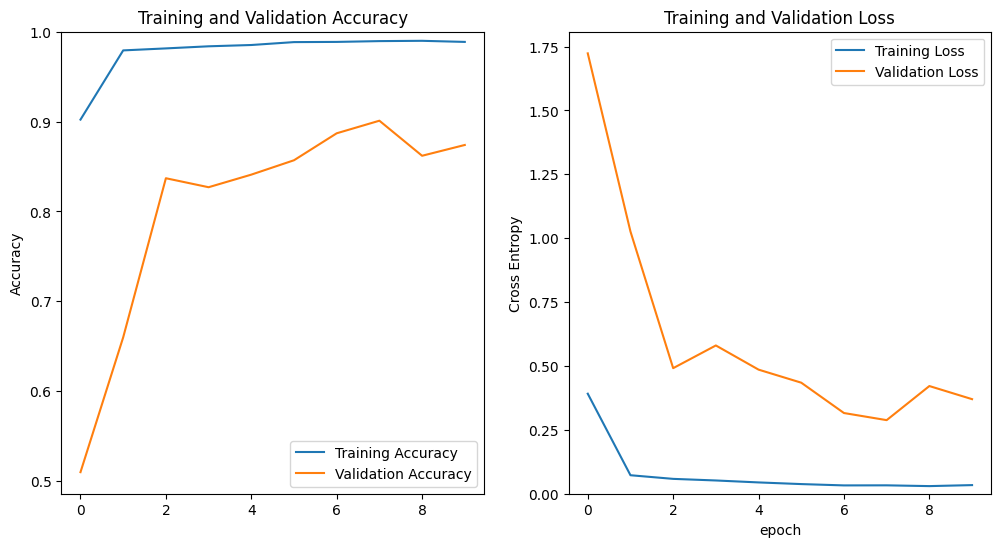

In [ ]:
import matplotlib.pyplot as plt

# Combine history objects from initial training and fine-tuning
# Ensure both history and history_fine_tune are available
if 'history' in locals():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.ylabel('Accuracy')
    plt.ylim([min(plt.ylim()),1])
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.ylabel('Cross Entropy')
    plt.ylim([0,max(plt.ylim())])
    plt.title('Training and Validation Loss')
    plt.xlabel('epoch')
    plt.show()
else:
    print("Training history objects ('history' or 'history_fine_tune') not found. Please ensure the model has been trained.")